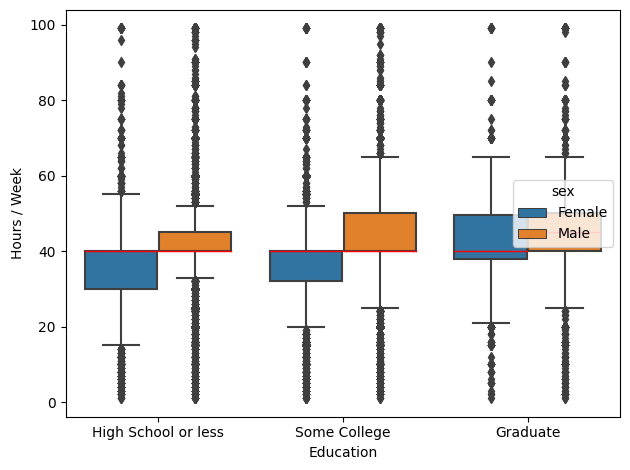

In [23]:
from sklearn.datasets import fetch_openml
import seaborn as sns
import matplotlib.pyplot as plt

df = fetch_openml('adult', version=2, as_frame=True).frame

df['edu_group'] = df['education-num'].apply(
    lambda x: 'High School or less' if x <= 9 else ('Some College' if x <= 13 else 'Graduate')
)

sns.boxplot(data=df, x='edu_group', y='hours-per-week', hue='sex',
            order=['High School or less', 'Some College', 'Graduate'],
            medianprops=dict(color='red', linewidth=1))
plt.ylabel('Hours / Week')
plt.xlabel('Education')
plt.tight_layout()
plt.show()

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

df = fetch_openml('adult', version=2, as_frame=True).frame.dropna()
df['age']          = df['age'].astype(float)
df['hours-per-week'] = df['hours-per-week'].astype(float)
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40.0,United-States,<=50K
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50.0,United-States,<=50K
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40.0,United-States,>50K
3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40.0,United-States,>50K
5,34.0,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30.0,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27.0,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38.0,United-States,<=50K
48838,40.0,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40.0,United-States,>50K
48839,58.0,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40.0,United-States,<=50K
48840,22.0,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20.0,United-States,<=50K


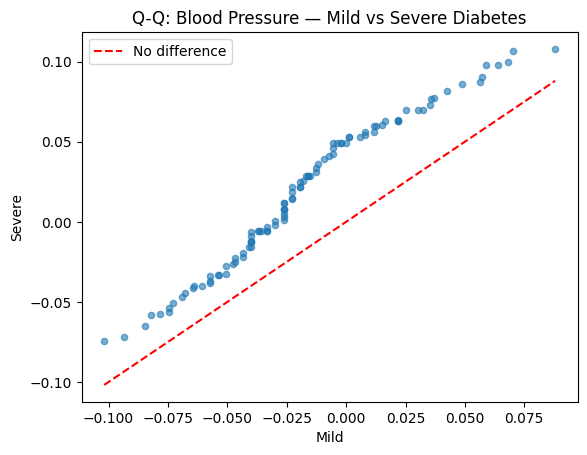

In [44]:
from sklearn.datasets import load_diabetes
import numpy as np
import matplotlib.pyplot as plt

df = load_diabetes(as_frame=True).frame
median = df['target'].median()

mild   = df[df['target'] <= median]['bp']
severe = df[df['target'] >  median]['bp']

q1, q2 = [np.quantile(g, np.linspace(0.01, 0.99, 100)) for g in (mild, severe)]

plt.scatter(q1, q2, alpha=0.6, s=20)
plt.plot([q1.min(), q1.max()], [q1.min(), q1.max()], 'r--', label='No difference')
plt.xlabel('Mild'); plt.ylabel('Severe')
plt.title('Q-Q: Blood Pressure — Mild vs Severe Diabetes')
plt.legend(); plt.show()

In [52]:
df['class']

0      present
1       absent
2      present
3       absent
4       absent
        ...   
265     absent
266     absent
267     absent
268     absent
269    present
Name: class, Length: 270, dtype: category
Categories (2, object): ['absent', 'present']

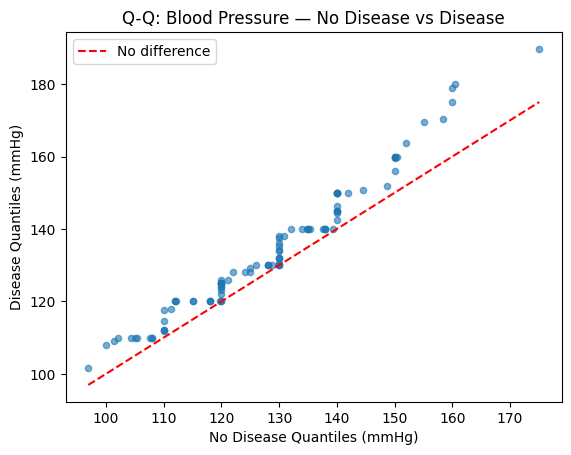

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

df = fetch_openml('heart-statlog', as_frame=True).frame

bp_no  = df[df['class']=='absent']['resting_blood_pressure'].dropna()
bp_yes = df[df['class']=='present']['resting_blood_pressure'].dropna()

q1, q2 = [np.quantile(g, np.linspace(0.01, 0.99, 100)) for g in (bp_no, bp_yes)]

plt.scatter(q1, q2, alpha=0.6, s=20)
plt.plot([q1.min(), q1.max()], [q1.min(), q1.max()], 'r--', label='No difference')
plt.xlabel('No Disease Quantiles (mmHg)')
plt.ylabel('Disease Quantiles (mmHg)')
plt.title('Q-Q: Blood Pressure — No Disease vs Disease')
plt.legend()
plt.show()

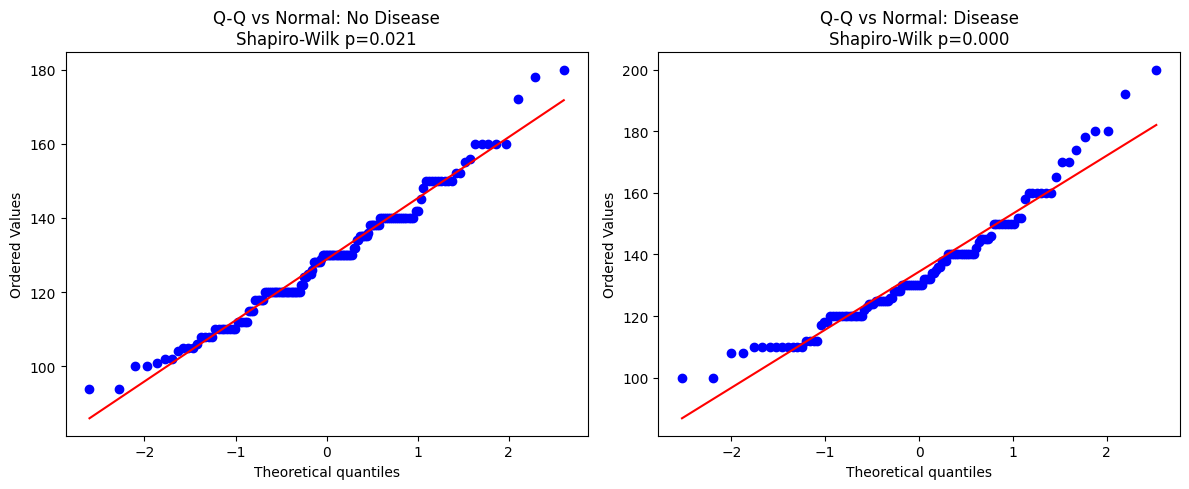

In [81]:
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

df = fetch_openml('heart-statlog', as_frame=True).frame
bp_no  = df[df['class']=='absent']['resting_blood_pressure'].dropna()
bp_yes = df[df['class']=='present']['resting_blood_pressure'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, group, label in zip(axes, [bp_no, bp_yes], ['No Disease', 'Disease']):
    _, p = stats.shapiro(group)
    stats.probplot(group, dist="norm", plot=ax)
    ax.set_title(f'Q-Q vs Normal: {label}\nShapiro-Wilk p={p:.3f}')

plt.tight_layout()
plt.show()

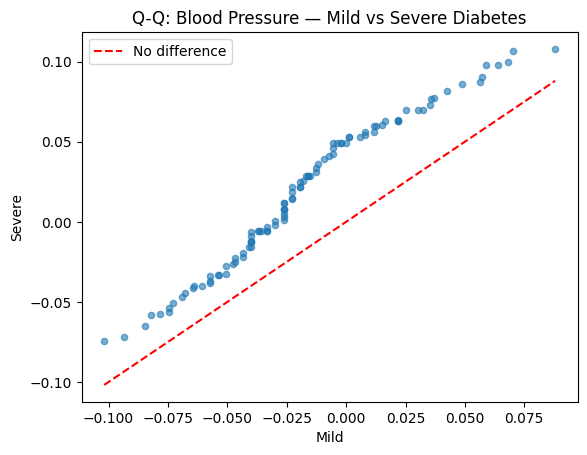

In [71]:
from sklearn.datasets import load_diabetes
import numpy as np
import matplotlib.pyplot as plt

df = load_diabetes(as_frame=True).frame
median = df['target'].median()

mild   = df[df['target'] <= median]['bp']
severe = df[df['target'] >  median]['bp']

q1, q2 = [np.quantile(g, np.linspace(0.01, 0.99, 100)) for g in (mild, severe)]

plt.scatter(q1, q2, alpha=0.6, s=20)
plt.plot([q1.min(), q1.max()], [q1.min(), q1.max()], 'r--', label='No difference')
plt.xlabel('Mild'); plt.ylabel('Severe')
plt.title('Q-Q: Blood Pressure — Mild vs Severe Diabetes')
plt.legend(); plt.show()

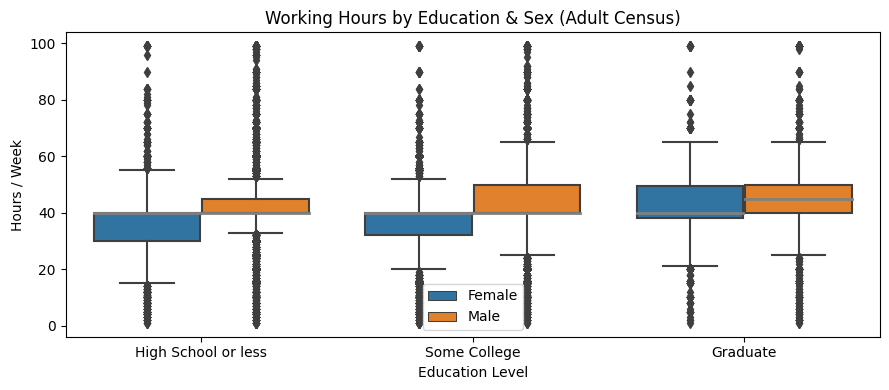

In [29]:
from sklearn.datasets import fetch_openml
import seaborn as sns
import matplotlib.pyplot as plt

df = fetch_openml('adult', version=2, as_frame=True).frame
df['edu_group'] = df['education-num'].apply(
    lambda x: 'High School or less' if x <= 9 else ('Some College' if x <= 13 else 'Graduate')
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df, x='edu_group', y='hours-per-week', hue='sex',
            order=['High School or less', 'Some College', 'Graduate'],
            medianprops=dict(color='gray', linewidth=2.0), ax=ax)
ax.set_ylabel('Hours / Week')
ax.set_xlabel('Education Level')
ax.set_title('Working Hours by Education & Sex (Adult Census)')

ax.legend()

plt.tight_layout()
plt.show()

In [34]:
print(plt.boxplot.__doc__)

Draw a box and whisker plot.

The box extends from the first quartile (Q1) to the third
quartile (Q3) of the data, with a line at the median.  The
whiskers extend from the box by 1.5x the inter-quartile range
(IQR).  Flier points are those past the end of the whiskers.
See https://en.wikipedia.org/wiki/Box_plot for reference.

.. code-block:: none

          Q1-1.5IQR   Q1   median  Q3   Q3+1.5IQR
                       |-----:-----|
       o      |--------|     :     |--------|    o  o
                       |-----:-----|
     flier             <----------->            fliers
                            IQR


Parameters
----------
x : Array or a sequence of vectors.
    The input data.  If a 2D array, a boxplot is drawn for each column
    in *x*.  If a sequence of 1D arrays, a boxplot is drawn for each
    array in *x*.

notch : bool, default: False
    Whether to draw a notched boxplot (`True`), or a rectangular
    boxplot (`False`).  The notches represent the confidence interval
 

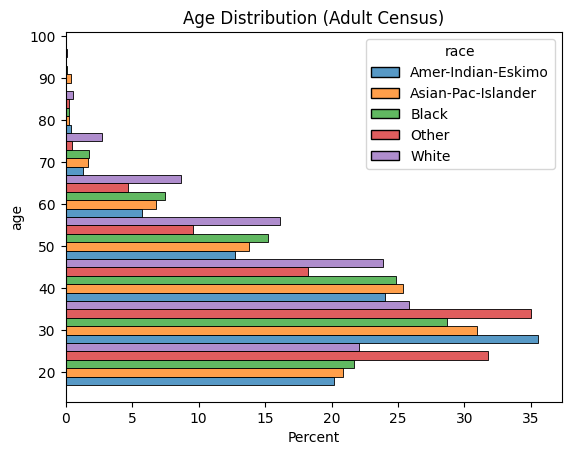

In [65]:
import seaborn as sns
from sklearn.datasets import fetch_openml

df = fetch_openml('adult', version=2, as_frame=True).frame

fig = sns.histplot(data=df,y='age',hue='race',stat='percent', common_norm=False, binwidth=10,multiple='dodge')
_ = fig.set_title("Age Distribution (Adult Census)")

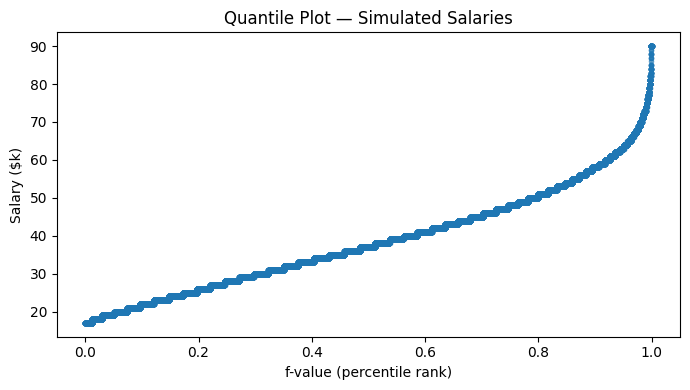

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

df = fetch_openml('adult', version=2, as_frame=True).frame

y = df['age'].sort_values()
N = len(y)
f = (np.arange(1, N+1) - 0.5) / N

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(f, y, 'o', markersize=3, alpha=0.6)
ax.set_xlabel('f-value (percentile rank)')
ax.set_ylabel('Salary ($k)')
ax.set_title('Quantile Plot — Simulated Salaries')
# for q, label in zip([0.25, 0.5, 0.75], ['Q1', 'Q2', 'Q3']):
#     ax.axvline(q, color='red', lw=0.8, ls='--', alpha=0.7)
#     ax.text(q + 0.01, salaries[-1] / 1000 * 0.95, label, color='red', fontsize=8)
plt.tight_layout()
plt.show()

<AxesSubplot: >

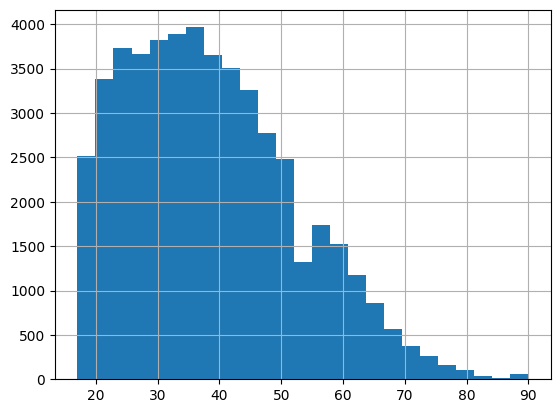

In [ ]:
df['age'].hist(bins=25, )

<AxesSubplot: xlabel='Percent', ylabel='age'>

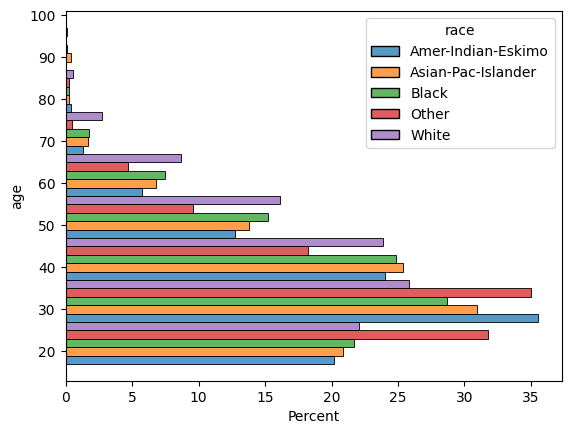

<AxesSubplot: >

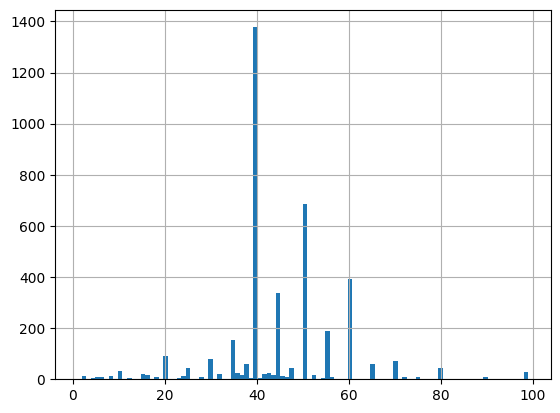

In [23]:
mask = df['edu_group'] == 'Graduate'
df[mask]['hours-per-week'].hist(bins=100)

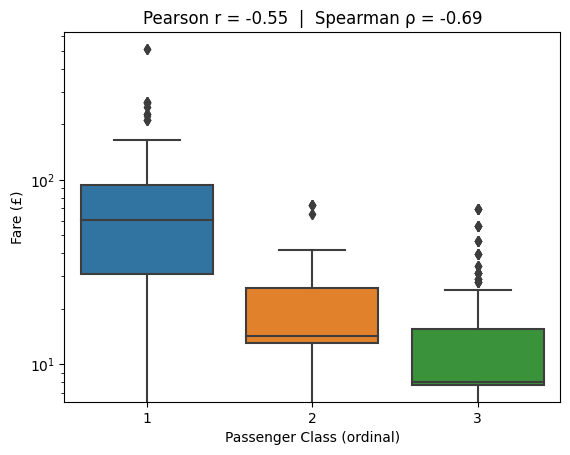

In [75]:
import seaborn as sns
from scipy import stats

titanic = sns.load_dataset('titanic')[['pclass', 'fare']].dropna()

r,   _ = stats.pearsonr(titanic['pclass'], titanic['fare'])
rho, _ = stats.spearmanr(titanic['pclass'], titanic['fare'])

ax = sns.boxplot(data=titanic, x='pclass', y='fare')
_ = ax.set(yscale='log', xlabel='Passenger Class (ordinal)', ylabel='Fare (£)',
       title=f'Pearson r = {r:.2f}  |  Spearman ρ = {rho:.2f}')

In [69]:
# Quick workaround at the top of your notebook
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

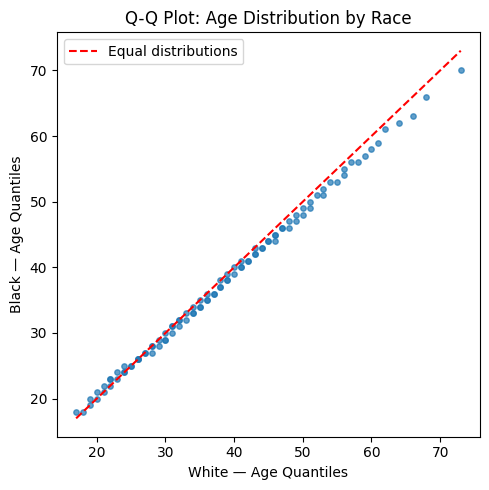

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

df = fetch_openml('adult', version=2, as_frame=True).frame.dropna()
df['age'] = df['age'].astype(float)

white = df[df['race'] == 'White']['age']
black = df[df['race'] == 'Black']['age']

percentiles = np.linspace(0.01, 0.99, 100)
q_white = np.quantile(white, percentiles)
q_black = np.quantile(black, percentiles)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(q_white, q_black, s=15, alpha=0.7)
ref = [min(q_white.min(), q_black.min()), max(q_white.max(), q_black.max())]
ax.plot(ref, ref, 'r--', label='Equal distributions')
ax.set_xlabel('White — Age Quantiles')
ax.set_ylabel('Black — Age Quantiles')
ax.set_title('Q-Q Plot: Age Distribution by Race')
ax.legend()
plt.tight_layout()
plt.show()

In [82]:
from scipy.stats import chi2_contingency
from sklearn.datasets import fetch_openml

# --- Example 1: Smoking vs Cancer (synthetic, asymmetric) ---
q, r, s, t = 50, 150, 10, 790

d_asymm = (r + s) / (q + r + s)
jaccard  = q / (q + r + s)
chi2, p_value, _, _ = chi2_contingency([[q, r], [s, t]])

print("Smoking vs Cancer")
print(f"  Asymmetric dissimilarity: {d_asymm:.3f}")
print(f"  Jaccard similarity:       {jaccard:.3f}")
print(f"  Chi-square: {chi2:.2f}, p-value: {p_value:.4f}")

# --- Example 2: Gender vs Income (Adult Census, real data) ---
df = fetch_openml('adult', version=2, as_frame=True).frame.dropna()
ct = df.groupby(['sex', 'class']).size().unstack()  # 'class' = income <=50K / >50K
print("\nGender vs Income — contingency table:")
print(ct)

chi2, p, _, expected = chi2_contingency(ct)
print(f"\n  Chi-square: {chi2:.2f}, p-value: {p:.4e}")

# Jaccard: treat '>50K & Female' as the rare positive
q = ct.loc['Female', '>50K']
r = ct.loc['Female', '<=50K']
s = ct.loc['Male',   '>50K']
jaccard = q / (q + r + s)
print(f"  Jaccard (Female & >50K): {jaccard:.3f}")

Smoking vs Cancer
  Asymmetric dissimilarity: 0.762
  Jaccard similarity:       0.238
  Chi-square: 155.83, p-value: 0.0000

Gender vs Income — contingency table:
class   <=50K  >50K
sex                
Female  13026  1669
Male    20988  9539

  Chi-square: 2104.13, p-value: 0.0000e+00
  Jaccard (Female & >50K): 0.069


In [ ]:
from scipy.stats import chi2_contingency
from sklearn.datasets import fetch_openml
from IPython.display import display

df = fetch_openml('adult', version=2, as_frame=True).frame.dropna()
ct = df.groupby(['sex', 'class']).size().unstack()

stat = chi2_contingency(ct)

ct['% of total'] = (ct.sum(axis=1) / ct.sum().sum() * 100).round(1)
display(ct)
print(stat)

class,<=50K,>50K
sex,,
Female,13026,1669
Male,20988,9539


Chi2ContingencyResult(statistic=2104.1337213723855, pvalue=0.0, dof=1, expected_freq=array([[11052.93286453,  3642.06713547],
       [22961.06713547,  7565.93286453]]))

In [126]:
import pandas as pd
import numpy as np

# example text documents
emails = {
    "spam1": "buy cheap meds free offer click now",
    "spam2": "free prize win offer click now",
    "ham1":  "meeting agenda attached",
    "ham2":  "send report meeting tomorrow",
}

# build vocabulary and count words into vectors
vocab = sorted(set(w for text in emails.values() for w in text.split()))
def count_vec(text):
    words = text.split()
    return np.array([words.count(w) for w in vocab])

print("term-document frequencies")

vecs = {k: count_vec(v) for k, v in emails.items()}
tf_freqs= pd.DataFrame(vecs, index=vocab)
display(tf_freqs)

def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# compute cosine similarities

pairs = [("spam1","spam2"), ("ham1","ham2"), ("spam1","ham1"), ("spam2","ham2")]
scores = [cosine(tf_freqs[a],tf_freqs[b]) for a,b in pairs]
sims  = pd.DataFrame(index=pairs,data=scores)
display(sims)


term-document frequencies


,spam1,spam2,ham1,ham2
agenda,0,0,1,0
attached,0,0,1,0
buy,1,0,0,0
cheap,1,0,0,0
click,1,1,0,0
free,1,1,0,0
meds,1,0,0,0
meeting,0,0,1,1
now,1,1,0,0
offer,1,1,0,0


,0
"(spam1, spam2)",0.617213
"(ham1, ham2)",0.288675
"(spam1, ham1)",0.000000
"(spam2, ham2)",0.000000


In [128]:
from rdkit import Chem
from rdkit.Chem import DataStructs, rdMolDescriptors
import pandas as pd

# Aspirin, Ibuprofen, Caffeine, Ethanol
smiles = {
    "Aspirin":   "CC(=O)Oc1ccccc1C(=O)O",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Caffeine":  "Cn1cnc2c1c(=O)n(c(=O)n2C)C",
    "Ethanol":   "CCO",
}

fps = {name: rdMolDescriptors.GetMorganFingerprintAsBitVect(
           Chem.MolFromSmiles(s), radius=2)
       for name, s in smiles.items()}

names = list(fps.keys())
tc = pd.DataFrame(index=names, columns=names)
for a in names:
    for b in names:
        tc.loc[a, b] = round(DataStructs.TanimotoSimilarity(fps[a], fps[b]), 3)

display(tc)

[10:55:59] DEPRECATION WARNING: please use MorganGenerator
[10:55:59] DEPRECATION WARNING: please use MorganGenerator
[10:55:59] DEPRECATION WARNING: please use MorganGenerator
[10:55:59] DEPRECATION WARNING: please use MorganGenerator


,Aspirin,Ibuprofen,Caffeine,Ethanol
Aspirin,1.0,0.195,0.089,0.111
Ibuprofen,0.195,1.0,0.087,0.107
Caffeine,0.089,0.087,1.0,0.033
Ethanol,0.111,0.107,0.033,1.0


Text(0.5, 1.02, 'Age vs Hours Worked — Income (color) × Sex (shape)')

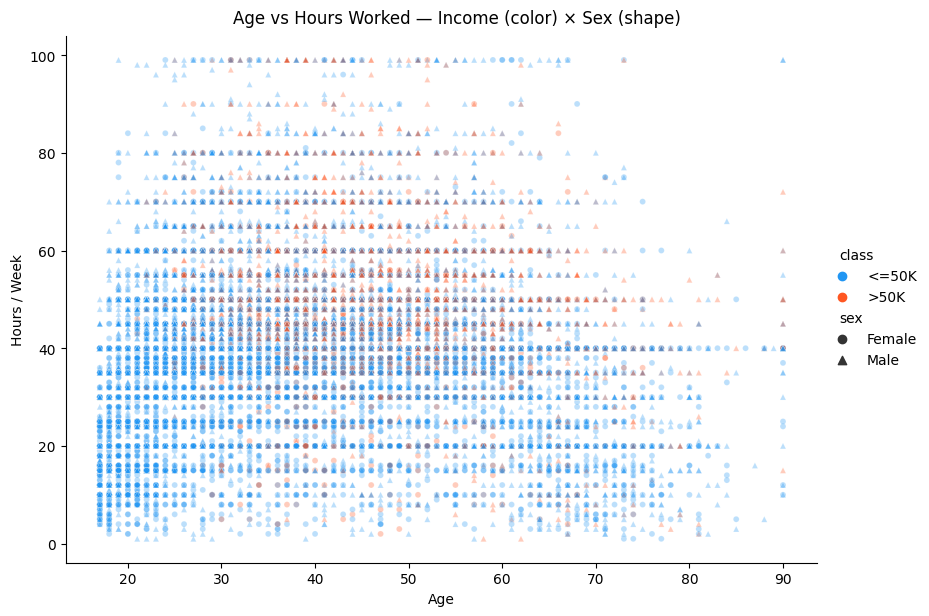

In [135]:
import seaborn as sns
from sklearn.datasets import fetch_openml

df = fetch_openml('adult', version=2, as_frame=True).frame.dropna()
df['age']            = df['age'].astype(float)
df['hours-per-week'] = df['hours-per-week'].astype(float)

g = sns.relplot(
    data=df, x='age', y='hours-per-week',
    hue='class', style='sex',
    palette={'<=50K': '#2196F3', '>50K': '#FF5722'},  # vivid blue / deep orange
    markers={'Male': '^', 'Female': 'o'},              # ▲ male, ○ female
    alpha=0.3, s=18, height=6, aspect=1.4
)
g.set_axis_labels('Age', 'Hours / Week')
g.figure.suptitle('Age vs Hours Worked — Income (color) × Sex (shape)', y=1.02)

In [139]:
import plotly.express as px
from sklearn.datasets import fetch_openml

df = fetch_openml('adult', version=2, as_frame=True).frame.dropna()
df['hours-per-week'] = df['hours-per-week'].astype(float)
df['age']            = df['age'].astype(float)

# Interactive boxplot — hover to inspect extreme workers
fig = px.box(
    df, x='class', y='hours-per-week',
    color='class',
    color_discrete_map={'<=50K': '#2196F3', '>50K': '#FF5722'},
    points='suspectedoutliers',          # only show outlier points
    hover_data=['age', 'sex', 'occupation'],
    labels={'class': 'Income', 'hours-per-week': 'Hours / Week'},
    title='Hours Worked per Week — outliers beyond 1.5×IQR shown individually'
)

# Reference line at 100h
fig.add_hline(y=100, line_dash='dash', line_color='gray',
              annotation_text='100h threshold', annotation_position='top right')

fig.update_layout(showlegend=False, height=450)
fig.show()

In [108]:
chi2_contingency(ct)

Chi2ContingencyResult(statistic=2105.2002032899736, pvalue=0.0, dof=2, expected_freq=array([[11052.93643264,  3642.0683112 ,    32.49525617],
       [22961.06356736,  7565.9316888 ,    67.50474383]]))